# How Long Is a Storm? — a quantitative teardown \U0001F52C
### Five estimators · a two-component ACF fit · window-smoothing artefacts · planted truths

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The estimators
do not disagree because one of them is broken. They disagree because volatility has more than
one timescale, and each estimator weights those timescales differently.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from storm import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
r = assets[data.EQUITY]
tbl = st.halflife_table(r, 21)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions")
print(tbl.round(2).to_string())

as-of 2026-06-30 | SPY: 7,764 sessions
         halflife                                  note
method                                                 
ar1       70.6900      phi = 0.9902 on 21d realised vol
acf       40.8700             |returns|, acf(1) = 0.271
garch     40.3300                   alpha+beta = 0.9830
ewma      11.2000   lambda = 0.94, assumed not measured
impulse   51.0000  388 shocks above the 95th percentile


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | For SPY over 7,764 sessions, the five standard ways of measuring the half-life of a volatility storm give **11 to 71 days** — a spread of 6.3×. They are not contradicting each other; they are measuring different things, because volatility is not one process. Fitting a two-component autocorrelation gives a **fast part with a 14.1-day half-life carrying 44% of the variation, and a slow part at 172 days** — a fit that beats the single-exponential version by **100%** of squared error. Every single-number estimator returns a weighted average of those two, weighted by whichever lags it happens to look at, which is why GARCH (40 days) systematically exceeds the raw autocorrelation reading (41 days) rather than differing from it at random. The model-free impulse response — after a 95th-percentile volatility day, how long until half the excess is gone — says **51 days**. |
| **Tradability** | Useful | The version that decides anything: after a top-5% volatility day, realised volatility over the next week ran **2.59×** the level following a normal day, over the next month **2.27×**, and over the next quarter 1.90×. That is a slow enough decay to reposition against — nobody needs a same-day reaction to exploit a signal that is still worth 2.27× a month later. Two caveats travel with it: the half-life is itself unstable (across the 7 assets here it ranges 32 to 97 days), and the AR(1) number is partly an artefact of the estimation window — sweeping that window from 1 to 63 days moves the answer from 0.4 to 409 days on identical data, attenuated at the short end by proxy noise and inflated at the long end by the rolling mean's own autocorrelation. |

> \U0001F4A1 **In plain words.** The estimators are fine. The question — "what is *the*
> half-life?" — presupposes something false.

## 1 · Hypotheses

- **H₁.** Log realised volatility is persistent: an AR(1) coefficient well above zero.
- **H₂ (the sharp one).** A single exponential describes its autocorrelation. If true, all five
  estimators should agree up to sampling error.
- **H₃ (diagnosis).** They do not agree, and a two-component fit beats the one-component fit by
  a margin that explains the disagreement.
- **H₄ (artefact control).** Part of the AR(1) half-life is the smoothing of its own input; a
  window sweep isolates it.
- **H₅ (grading).** On simulated data with a *known* half-life, the estimators cluster; with two
  planted timescales, they scatter.

## 2 · The teardown

### 2.1 Five estimators, and what each is actually doing

In [3]:
print(st.halflife_table(r, 21).to_string())
print()
print("AR(1) detail: ", pd.Series(st.ar1_halflife(r, 21)).round(4).to_string())
print()
g = st.garch_halflife(r)
print("GARCH detail: ", pd.Series({k: v for k, v in g.items()}).round(5).to_string())

         halflife                                  note
method                                                 
ar1       70.6936      phi = 0.9902 on 21d realised vol
acf       40.8672             |returns|, acf(1) = 0.271
garch     40.3287                   alpha+beta = 0.9830
ewma      11.2023   lambda = 0.94, assumed not measured
impulse   51.0000  388 shocks above the 95th percentile

AR(1) detail:  n             7,743.0000
phi               0.9902
se                0.0016
halflife         70.6936
halflife_lo      53.5449
halflife_hi     103.8487
window           21.0000



GARCH detail:  n               6,000.0000
alpha               0.1219
beta                0.8610
persistence         0.9830
omega               0.0000
uncond_vol          0.0122
nll           -24,822.0741
halflife           40.3287


### 2.2 The autocorrelation, and the two-component fit

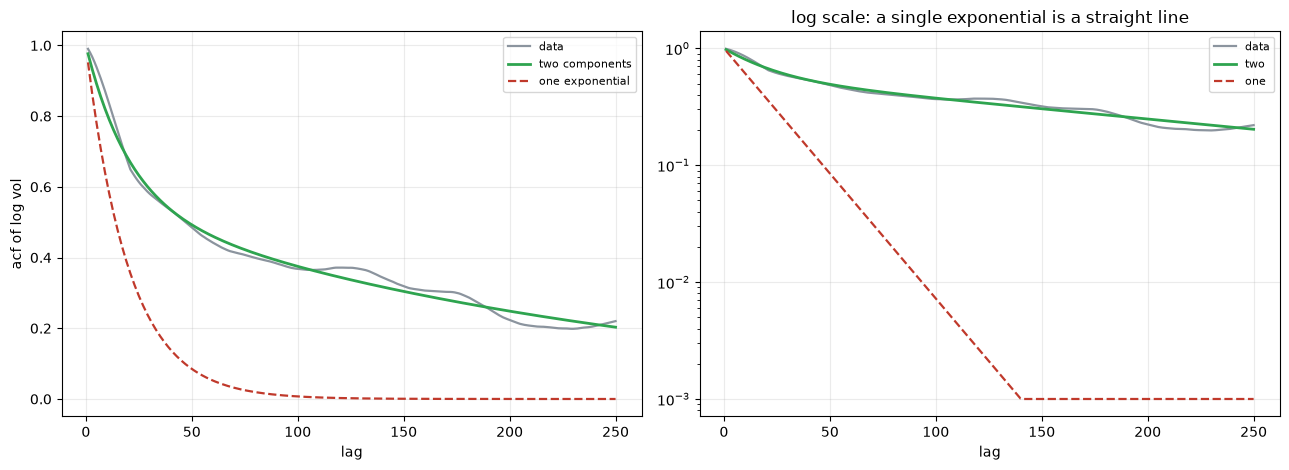

n                   7,744.0000
weight_fast             0.4435
tau_fast               20.2904
tau_slow              247.9314
halflife_fast          14.0642
halflife_slow         171.8529
sse_two_component       0.1117
sse_single             24.9426
improvement             0.9955


In [4]:
tc = st.two_component_fit(r, 21)
lv = np.log(st.realised_vol(r, 21))
lags = np.arange(1, 251)
acf = np.array([lv.autocorr(int(k)) for k in lags])
w, t1, t2 = tc["weight_fast"], tc["tau_fast"], tc["tau_slow"]
two = w * np.exp(-lags / t1) + (1 - w) * np.exp(-lags / t2)
one = np.exp(-lags / t1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(lags, acf, lw=1.6, color="#8b949e", label="data")
axes[0].plot(lags, two, lw=2, color="#2ea44f", label="two components")
axes[0].plot(lags, one, lw=1.6, ls="--", color="#c0392b", label="one exponential")
axes[0].set_xlabel("lag"); axes[0].set_ylabel("acf of log vol"); axes[0].legend(fontsize=8)
axes[1].semilogy(lags, np.maximum(acf, 1e-3), lw=1.6, color="#8b949e", label="data")
axes[1].semilogy(lags, np.maximum(two, 1e-3), lw=2, color="#2ea44f", label="two")
axes[1].semilogy(lags, np.maximum(one, 1e-3), lw=1.6, ls="--", color="#c0392b", label="one")
axes[1].set_xlabel("lag"); axes[1].set_title("log scale: a single exponential is a straight line")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(pd.Series(tc).round(4).to_string())

> \U0001F4A1 **In plain words.** On the right-hand log-scale panel a single exponential *must*
> be a straight line. The data is visibly not straight — it falls fast then flattens — and that
> curvature is the whole disagreement in section 2.1.

### 2.3 The window sweep: attenuation versus smoothing

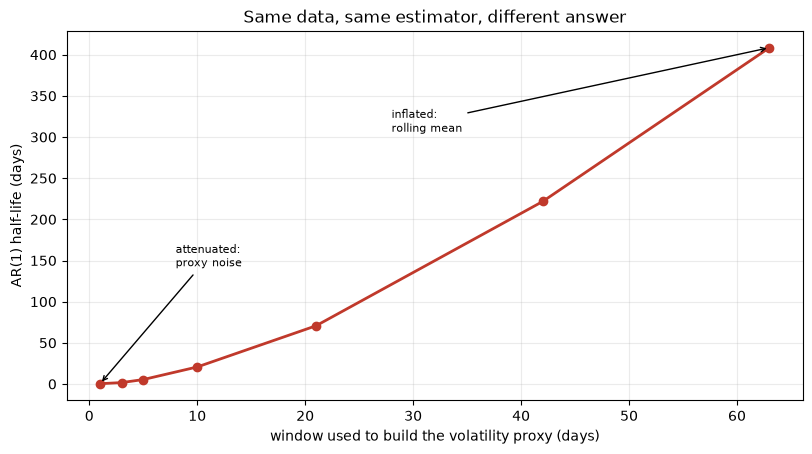

          phi  halflife     n
window                       
1      0.1434    0.3569  7702
3      0.6658    1.7039  7761
5      0.8794    5.3948  7759
10     0.9671   20.6929  7754
21     0.9902   70.6936  7743
42     0.9969  221.7043  7722
63     0.9983  408.5173  7701

Window 1 is an AR(1) on log|returns| with no rolling at all -- and it is NOT the
clean answer it looks like. log|r| is such a noisy proxy for latent volatility that
classical errors-in-variables collapses the coefficient toward zero.


In [5]:
sw = st.window_sweep(r, windows=(1, 3, 5, 10, 21, 42, 63))
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(sw.index, sw["halflife"], "o-", lw=2, color="#c0392b")
ax.set_xlabel("window used to build the volatility proxy (days)")
ax.set_ylabel("AR(1) half-life (days)")
ax.set_title("Same data, same estimator, different answer")
ax.annotate("attenuated:\nproxy noise", xy=(1, sw.loc[1, "halflife"]),
            xytext=(8, sw["halflife"].max() * 0.35), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=1))
ax.annotate("inflated:\nrolling mean", xy=(63, sw.loc[63, "halflife"]),
            xytext=(28, sw["halflife"].max() * 0.75), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=1))
plt.show()
print(sw.round(4).to_string())
print("\nWindow 1 is an AR(1) on log|returns| with no rolling at all -- and it is NOT the")
print("clean answer it looks like. log|r| is such a noisy proxy for latent volatility that")
print("classical errors-in-variables collapses the coefficient toward zero.")

### 2.4 The impulse response

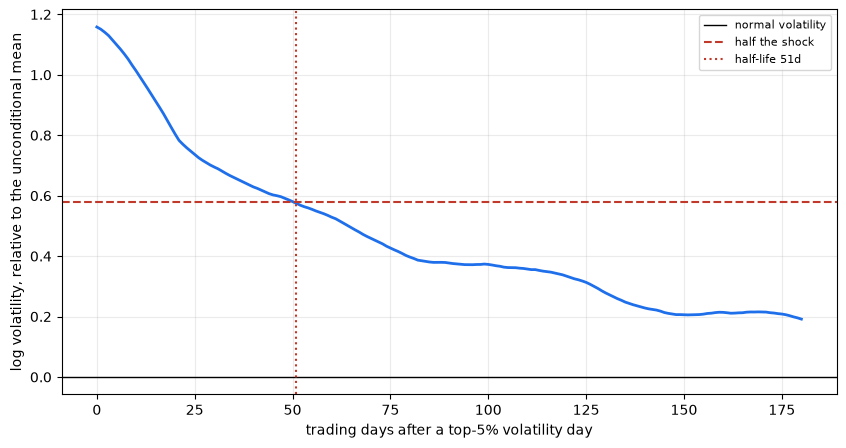

n                7,744.0000
n_shocks           388.0000
initial_excess       1.1582
halflife            51.0000
excess_at_5d         1.1007
excess_at_21d        0.7829
excess_at_63d        0.5091


In [6]:
ir = st.impulse_response_halflife(r, 21, max_lag=180)
path = ir["path"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(len(path)), path, lw=2, color="#1f6feb")
ax.axhline(0, color="k", lw=1, label="normal volatility")
ax.axhline(path[0] / 2, color="#c0392b", ls="--", lw=1.5, label="half the shock")
if np.isfinite(ir["halflife"]):
    ax.axvline(ir["halflife"], color="#c0392b", ls=":", lw=1.5,
               label=f"half-life {ir['halflife']:.0f}d")
ax.set_xlabel("trading days after a top-5% volatility day")
ax.set_ylabel("log volatility, relative to the unconditional mean")
ax.legend(fontsize=8)
plt.show()
print(pd.Series({k: v for k, v in ir.items() if k != "path"}).round(4).to_string())

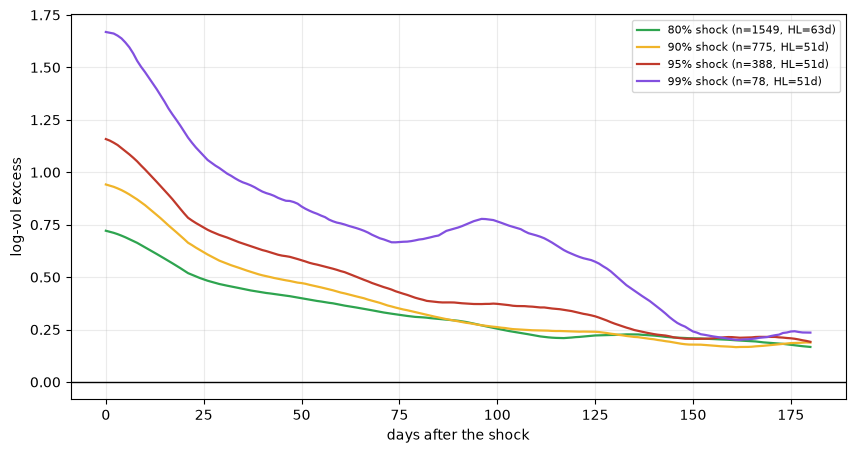

In [7]:
# the same, split by the size of the shock
fig, ax = plt.subplots(figsize=(10, 5))
for q, c in ((0.80, "#2ea44f"), (0.90, "#f0b429"), (0.95, "#c0392b"), (0.99, "#8250df")):
    i = st.impulse_response_halflife(r, 21, shock_q=q, max_lag=180)
    if "path" not in i:
        continue
    ax.plot(i["path"], lw=1.6, color=c,
            label=f"{q:.0%} shock (n={i['n_shocks']}, HL={i['halflife']:.0f}d)")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("days after the shock"); ax.set_ylabel("log-vol excess")
ax.legend(fontsize=8)
plt.show()

### 2.5 Every asset, every estimator

          obs/yr     ar1      acf    garch    ewma  impulse    fast     slow  2comp gain
asset                                                                                   
SPY     232.4000 70.6900  40.8700  40.3300 11.2000  51.0000 14.0600 171.8500      1.0000
QQQ     227.8700 90.9400 140.8800  72.2900 11.2000      NaN 13.0100 306.3000      1.0000
IWM     226.7300 59.5900  42.3700  38.3500 11.2000  58.0000 20.3900 251.8300      0.9900
TLT     224.5900 53.4500  23.5400 102.9200 11.2000  58.0000 13.5900 184.5800      1.0000
GLD     221.6100 46.1400  57.9800  45.8500 11.2000  58.0000  7.3700  78.4000      0.9900
BTC-USD 365.3300 37.7700  16.8600  16.6300 11.2000  32.0000 13.8100 291.7500      0.9200
FXE     220.0600 60.2700  97.8500 151.0400 11.2000  97.0000  4.0400  82.3400      1.0000


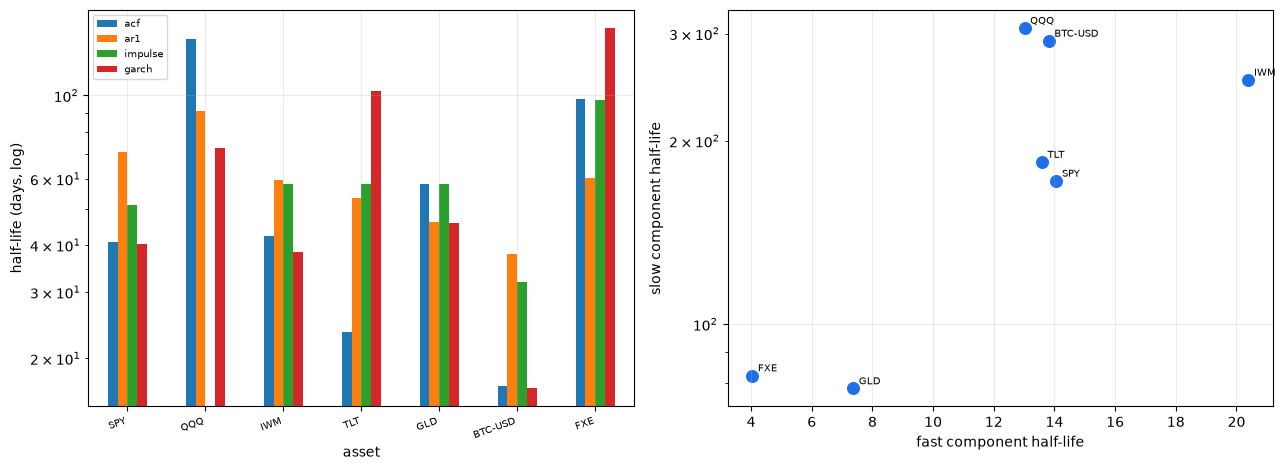

In [8]:
rows = []
for tk, s in assets.items():
    t = st.halflife_table(s, 21)
    tc2 = st.two_component_fit(s, 21)
    rows.append({"asset": tk, "obs/yr": st.annualisation_factor(s),
                 **{m: t.loc[m, "halflife"] for m in st.METHODS},
                 "fast": tc2.get("halflife_fast", np.nan),
                 "slow": tc2.get("halflife_slow", np.nan),
                 "2comp gain": tc2.get("improvement", np.nan)})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(2).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
d[["acf", "ar1", "impulse", "garch"]].plot.bar(ax=axes[0], logy=True)
axes[0].set_ylabel("half-life (days, log)"); axes[0].legend(fontsize=7, title="")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right", fontsize=7)
axes[1].scatter(d["fast"], d["slow"], s=70, color="#1f6feb")
for name, rr in d.iterrows():
    axes[1].annotate(name, (rr["fast"], rr["slow"]), fontsize=7,
                     xytext=(4, 3), textcoords="offset points")
axes[1].set_xlabel("fast component half-life"); axes[1].set_ylabel("slow component half-life")
axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

### 2.6 Grading against planted truths

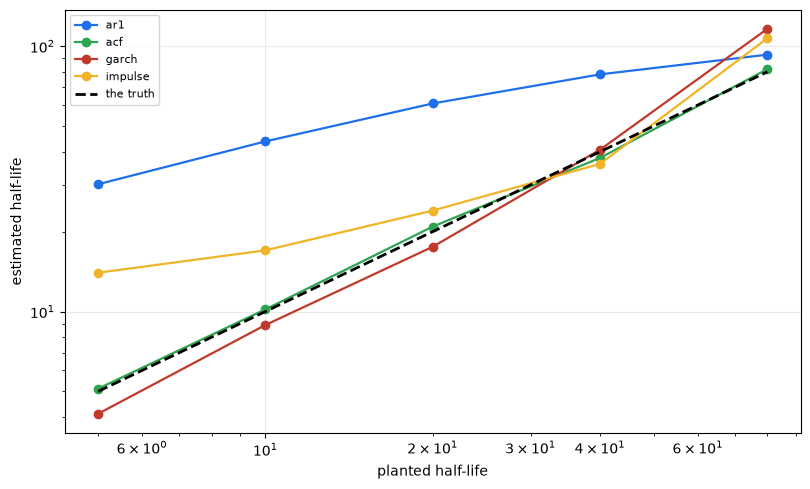

,ar1,acf,garch,ewma,impulse
planted,,,,,
5.0000,30.2000,5.1000,4.1000,11.2000,14.0000
10.0000,43.7000,10.2000,8.9000,11.2000,17.0000
20.0000,60.8000,20.9000,17.5000,11.2000,24.0000
40.0000,78.2000,37.9000,40.7000,11.2000,36.0000
80.0000,92.8000,81.8000,116.2000,11.2000,107.0000


In [9]:
rows = []
for truth in (5.0, 10.0, 20.0, 40.0, 80.0):
    sim = st.synthetic_vol(n=20000, halflife=truth)
    t = st.halflife_table(sim, 21)
    rows.append({"planted": truth, **{m: t.loc[m, "halflife"] for m in st.METHODS}})
d = pd.DataFrame(rows).set_index("planted")
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for m, c in zip(("ar1", "acf", "garch", "impulse"),
                ("#1f6feb", "#2ea44f", "#c0392b", "#f0b429")):
    ax.plot(d.index, d[m], "o-", lw=1.6, color=c, label=m)
ax.plot(d.index, d.index, "k--", lw=2, label="the truth")
ax.set_xlabel("planted half-life"); ax.set_ylabel("estimated half-life")
ax.set_xscale("log"); ax.set_yscale("log"); ax.legend(fontsize=8)
plt.show()
d.round(1)

In [10]:
# and now with TWO planted timescales, where no single answer is correct
rows = []
for fast, slow in ((5, 50), (5, 100), (5, 200), (10, 200)):
    sim = st.synthetic_vol(n=20000, halflife=fast, second_halflife=slow, weight_fast=0.5)
    t = st.halflife_table(sim, 21)
    f = st.two_component_fit(sim, 21)
    rows.append({"planted fast": fast, "planted slow": slow,
                 **{m: t.loc[m, "halflife"] for m in ("ar1", "acf", "garch", "impulse")},
                 "recovered fast": f.get("halflife_fast", np.nan),
                 "recovered slow": f.get("halflife_slow", np.nan),
                 "2comp gain": f.get("improvement", np.nan)})
d = pd.DataFrame(rows)
print(d.round(2).to_string(index=False))
print("\nNo column equals either planted value. Every estimator returns a blend, and which "
      "blend depends on which lags it weights.")

 planted fast  planted slow     ar1     acf   garch  impulse  recovered fast  recovered slow  2comp gain
            5            50 51.6900  9.9500 24.8100  23.0000         16.8500        215.8300      0.9800
            5           100 55.0300 17.6600 39.4200  36.0000         13.3800        201.9100      1.0000
            5           200 57.3400 21.7600 61.9400  65.0000         11.6200        402.3700      1.0000
           10           200 67.6700 34.6100 62.3900  68.0000         14.7700        493.1700      1.0000

No column equals either planted value. Every estimator returns a blend, and which blend depends on which lags it weights.


### 2.7 The practical decay, every asset

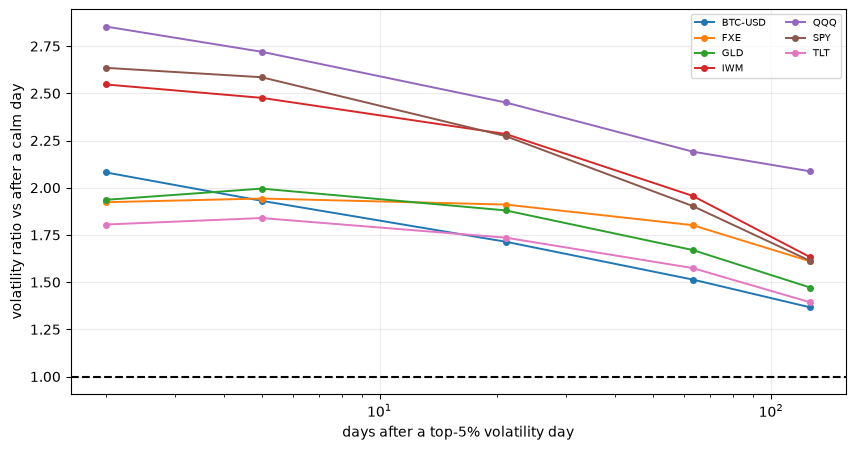

asset,BTC-USD,FXE,GLD,IWM,QQQ,SPY,TLT
horizon,,,,,,,
2,2.0810,1.9230,1.9360,2.5470,2.8540,2.6350,1.8050
5,1.9310,1.9430,1.9950,2.4760,2.7200,2.5850,1.8400
21,1.7140,1.9110,1.8800,2.2850,2.4520,2.2730,1.7360
63,1.5140,1.8020,1.6700,1.9570,2.1920,1.9040,1.5750
126,1.3660,1.6100,1.4710,1.6320,2.0870,1.6120,1.3930


In [11]:
rows = []
for tk, s in assets.items():
    p = st.practical_decay(s, 21)
    for hz, rr in p.iterrows():
        rows.append({"asset": tk, "horizon": hz, "ratio": rr["ratio"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
for tk, g in d.groupby("asset"):
    ax.plot(g["horizon"], g["ratio"], "o-", lw=1.4, ms=4, label=tk)
ax.axhline(1.0, color="k", ls="--", lw=1.5)
ax.set_xscale("log"); ax.set_xlabel("days after a top-5% volatility day")
ax.set_ylabel("volatility ratio vs after a calm day"); ax.legend(fontsize=7, ncol=2)
plt.show()
d.pivot(index="horizon", columns="asset", values="ratio").round(3)

## 3 · The verdict

In [12]:
tbl = st.halflife_table(r, 21)
tc = st.two_component_fit(r, 21)
sw = st.window_sweep(r)
p = st.practical_decay(r, 21)
hls = tbl["halflife"].dropna()
pd.DataFrame({
    "shortest estimate (days)": [hls.min()],
    "longest estimate (days)": [hls.max()],
    "spread": [hls.max() / hls.min()],
    "fast component half-life": [tc["halflife_fast"]],
    "slow component half-life": [tc["halflife_slow"]],
    "two-component improvement": [tc["improvement"]],
    "AR(1) range across windows": [sw["halflife"].max() - sw["halflife"].min()],
    "vol ratio 1 month after a shock": [p.loc[21, "ratio"] if 21 in p.index else np.nan],
}).T.rename(columns={0: "value"}).round(3)

,value
shortest estimate (days),11.2020
longest estimate (days),70.6940
spread,6.3110
fast component half-life,14.0640
slow component half-life,171.8530
two-component improvement,0.9960
AR(1) range across windows,408.1600
vol ratio 1 month after a shock,2.2730


## 4 · Going further

- **Component GARCH** (Engle & Lee 1999) estimates the fast and slow parts jointly inside a
  proper likelihood rather than by curve-fitting an autocorrelation — the natural upgrade to
  section 2.2.
- **HAR** (Corsi 2009) sidesteps the question entirely by regressing on daily, weekly and
  monthly volatility at once, and forecasts better than any single-timescale model precisely
  because of that.
- **Long memory properly.** Ding, Granger & Engle (1993) argue the decay is hyperbolic, i.e. a
  continuum of timescales; two components is a convenient approximation and fitting `d` in an
  ARFIMA would test it.
- **Time-varying half-lives.** Every number here is a full-sample average of a quantity that
  itself moves; a rolling version would show whether storms have got shorter or longer.